<a href="https://colab.research.google.com/github/toche7/SlideAIDATADGA/blob/main/Workshop3v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop 3: Data Preparation Pipeline

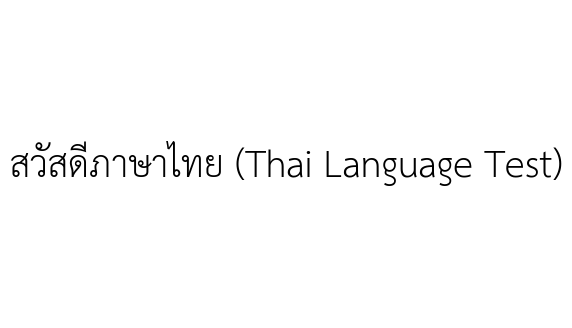

In [31]:
# ดาวน์โหลด TH Sarabun New
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

# 1) Import libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# เพิ่มฟอนต์เข้าระบบ Matplotlib
fm.fontManager.addfont('thsarabunnew-webfont.ttf')
# ตั้งค่า default font ให้เป็น TH Sarabun New
mpl.rc('font', family='TH Sarabun New')
plt.rcParams.update({'font.size': 14})

# ทดสอบการพล็อตภาษาไทย
plt.figure(figsize=(6, 4))
plt.text(0.5, 0.5, 'สวัสดีภาษาไทย (Thai Language Test)', fontsize=25, ha='center', va='center')
# plt.title('ทดสอบการแสดงผลภาษาไทย')
plt.axis('off')
plt.show()

## 1. การโหลดข้อมูล

ขั้นตอนนี้เราจะโหลดไฟล์ CSV ที่มีชื่อ `/content/traffic_accident.csv` เข้ามาใน DataFrame ของ Pandas เพื่อเริ่มต้นการวิเคราะห์ข้อมูล
เนื่องจากข้อมูลมีภาษาไทยและเกิดข้อผิดพลาดในการถอดรหัส (UnicodeDecodeError) เราจึงระบุ `encoding='TIS-620'` เพื่อให้สามารถอ่านไฟล์ได้อย่างถูกต้อง

In [32]:
url = "https://github.com/toche7/DataSets/raw/refs/heads/main/traffic_accident.csv"

In [33]:
df = pd.read_csv(url, encoding='TIS-620')
display(df.head())

,Province,Police station,Days of a week,road/bridge,Surface,Location,Location details,Condition,Quality,Traffic lines,Traffic light,Light Condition,Latitude,Longitude
0,ปทุมธานี,สภ.ปากคลองรังสิต,อังคาร,ทล.3508,แอสฟัลท์/ลาดยาง,ทางหลัก,ทางโค้ง,แห้ง,เรียบ (Smooth),มีและชัดเจน,ไม่มี,กลางคืนมีไฟถนน,13.964525,100.605137
1,ปทุมธานี,สภ.ปากคลองรังสิต,เสาร์,ทล.3508,แอสฟัลท์/ลาดยาง,ทางหลัก,ทางตรง,แห้ง,เรียบ (Smooth),มีและชัดเจน,ไม่มี,กลางคืนมีไฟถนน,13.970124,100.604463
2,ปทุมธานี,สภ.ปากคลองรังสิต,ศุกร์,ทล.3508,แอสฟัลท์/ลาดยาง,ทางหลัก,ทางตรง,แห้ง,เรียบ (Smooth),มีและชัดเจน,ไม่มี,กลางคืนมีไฟถนน,13.972153,100.604207
3,ปทุมธานี,สภ.ปากคลองรังสิต,จันทร์,ทล.3508,แอสฟัลท์/ลาดยาง,ทางหลัก,ทางตรง,แห้ง,เรียบ (Smooth),มีและชัดเจน,ไม่มี,กลางคืนไม่มีไฟถนน (มีเสาไฟแต่ใช้การไม่ได้),13.978680,100.603389
4,ปทุมธานี,สภ.สวนพริกไทย,อังคาร,อย.5042,คอนกรีต,ทางหลัก,ทางตรง,แห้ง,เรียบ (Smooth),มีและชัดเจน,ไม่มี,มืด,14.012316,100.595836


## 2. ตรวจสอบคุณภาพข้อมูลเบื้องต้น (ค่าที่ขาดหายไป)

หลังจากโหลดข้อมูลแล้ว เราจะตรวจสอบคุณภาพของข้อมูลโดยดูว่ามีค่าที่ขาดหายไป (Missing Values) อยู่ในคอลัมน์ใดบ้าง และคิดเป็นกี่เปอร์เซ็นต์ของข้อมูลทั้งหมด เพื่อประเมินผลกระทบที่อาจเกิดขึ้นต่อการวิเคราะห์

In [34]:
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Province          683 non-null    object 
 1   Police station    683 non-null    object 
 2   Days of a week    680 non-null    object 
 3   road/bridge       683 non-null    object 
 4   Surface           676 non-null    object 
 5   Location          677 non-null    object 
 6   Location details  682 non-null    object 
 7   Condition         678 non-null    object 
 8   Quality           682 non-null    object 
 9   Traffic lines     679 non-null    object 
 10  Traffic light     681 non-null    object 
 11  Light Condition   676 non-null    object 
 12  Latitude          683 non-null    float64
 13  Longitude         683 non-null    float64
dtypes: float64(2), object(12)
memory usage: 74.8+ KB


In [35]:
print('\nMissing values percentage per column:')
missing_percentage = df.isnull().sum() / len(df) * 100
display(missing_percentage[missing_percentage > 0].sort_values(ascending=False))


Missing values percentage per column:


,0
Surface,1.024890
Light Condition,1.024890
Location,0.878477
Condition,0.732064
Traffic lines,0.585652
Days of a week,0.439239
Traffic light,0.292826
Location details,0.146413
Quality,0.146413


## 3. การจัดการกับค่าที่ขาดหายไป

จากผลการตรวจสอบ เราพบว่ามีค่าที่ขาดหายไปเป็นจำนวนน้อยมาก (ต่ำกว่า 2%) ในหลายๆ คอลัมน์ เพื่อให้ข้อมูลสะอาดและพร้อมสำหรับการวิเคราะห์ในขั้นต่อไป เราจึงเลือกที่จะลบแถวข้อมูลที่มีค่าที่ขาดหายไปออกทั้งหมด และสร้างเป็น DataFrame ใหม่ชื่อ `df_cleaned` ซึ่งเป็นสำเนาที่สมบูรณ์ (deep copy) เพื่อหลีกเลี่ยงข้อผิดพลาด `SettingWithCopyWarning`

In [36]:
# Drop rows with any missing values
df_cleaned = df.dropna().copy()

print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape: {df_cleaned.shape}")

Original DataFrame shape: (683, 14)
Cleaned DataFrame shape: (652, 14)


## 4. ตรวจสอบค่าที่ขาดหายไปหลังการทำความสะอาด

หลังจากลบแถวที่มีค่าที่ขาดหายไปออกไปแล้ว เราจะตรวจสอบอีกครั้งเพื่อยืนยันว่าไม่มีค่าที่ขาดหายไปเหลืออยู่ใน `df_cleaned` แล้ว เพื่อให้มั่นใจว่าข้อมูลสะอาดจริง

In [37]:
# Verify that there are no more missing values
print('\nMissing values percentage after dropping rows:')
missing_percentage_cleaned = df_cleaned.isnull().sum() / len(df_cleaned) * 100
display(missing_percentage_cleaned[missing_percentage_cleaned > 0].sort_values(ascending=False))


Missing values percentage after dropping rows:


,0


## 5. ตรวจสอบค่าที่ไม่ซ้ำกันของแต่ละคอลัมน์

ขั้นตอนนี้เป็นการสำรวจข้อมูลเชิงลึกมากขึ้น โดยการแสดงค่าที่ไม่ซ้ำกันทั้งหมดในแต่ละคอลัมน์ของ `df_cleaned` เพื่อทำความเข้าใจประเภทของข้อมูลและความหลากหลายของข้อมูลในแต่ละแอตทริบิวต์ ช่วยให้เรามองเห็นรูปแบบหรือค่าผิดปกติได้ง่ายขึ้น

In [38]:
print("Unique values in 'Days of a week' column:")
display(df_cleaned['Days of a week'].unique())

Unique values in 'Days of a week' column:


array(['อังคาร', 'เสาร์', 'ศุกร์', 'จันทร์', 'พุธ', 'อาทิตย์', 'พฤหัส'],
      dtype=object)

In [39]:
for column in df_cleaned.columns:
    print(f"\nUnique values in '{column}' column:")
    print(df_cleaned[column].unique())


Unique values in 'Province' column:
['ปทุมธานี' 'นนทบุรี']

Unique values in 'Police station' column:
['สภ.ปากคลองรังสิต' 'สภ.สวนพริกไทย' 'สภ.สามโคก' 'สภ.ปากเกร็ด'
 'สภ.บางบัวทอง' 'สภ.เมืองนนทบุรี' 'สภ.รัตนาธิเบศร์' 'สภ.เมืองปทุมธานี'
 'สภ.ปลายบาง' 'สภ.บางกรวย' 'สภ.ชัยพฤกษ์' 'สภ.ไทรน้อย' 'สภ.บางศรีเมือง'
 'สภ.บางใหญ่' 'สภ.บางแม่นาง']

Unique values in 'Days of a week' column:
['อังคาร' 'เสาร์' 'ศุกร์' 'จันทร์' 'พุธ' 'อาทิตย์' 'พฤหัส']

Unique values in 'road/bridge' column:
['ทล.3508' 'อย.5042' 'ทล.346' 'ทล.3214' 'ทล.345' 'ถนนเลียบคลองเปรมประชากร'
 'ทางพิเศษอุดรรัถยา ' 'ทล.9' 'ทล.347' 'ถนนเลียบคลองประปา'
 'ถนนบางเลียบพัฒนา' 'นบ.3309' 'ซอยโรงถั่ว' 'ทล.306' 'ทล.307'
 'ถนนป๊อปปูล่า' 'นบ.ถ 3-0001' 'ถนนประชาชื่น' 'แยกเทคโน' 'ซอยวัดมะขาม'
 'ทล.304' 'ถนนเมืองทองธานี' 'ทล.302' 'ทางพิเศษศรีรัช' 'สะพานปทุมธานี'
 'สะพานปทุมธานี 1' 'หมู่บ้านเมืองทองธานีโครงการ 5' 'สะพานปทุมธานี2'
 'ถนนบางกะดีสายใน' 'สะพานนนทบุรี' 'นบ.3019' 'ซอยงามวงศ์วาน 21'
 'สะพานปทุมธานี 2' 'ถนนปทุมธานี-สายใน' 'แยกสันติสุข' 'ท

## 6. การปรับปรุงข้อมูล: ลบช่องว่างนำหน้า/ท้ายในคอลัมน์ 'road/bridge'

ตามคำแนะนำของคุณผู้ใช้ เราพบว่าคอลัมน์ 'road/bridge' อาจมีช่องว่างที่ไม่จำเป็นทั้งก่อนและหลังข้อความ ซึ่งอาจส่งผลต่อการวิเคราะห์หรือการจัดกลุ่มข้อมูล เพื่อแก้ไขปัญหานี้ เราจะใช้เมธอด `.str.strip()` เพื่อลบช่องว่างเหล่านั้นออก ทำให้ข้อมูลมีความสม่ำเสมอมากขึ้น และแสดงค่าที่ไม่ซ้ำกันอีกครั้งเพื่อยืนยันการเปลี่ยนแปลง

In [40]:
df_cleaned['road/bridge'] = df_cleaned['road/bridge'].str.strip()
print("Unique values in 'road/bridge' column after trimming spaces:")
print(df_cleaned['road/bridge'].unique())

Unique values in 'road/bridge' column after trimming spaces:
['ทล.3508' 'อย.5042' 'ทล.346' 'ทล.3214' 'ทล.345' 'ถนนเลียบคลองเปรมประชากร'
 'ทางพิเศษอุดรรัถยา' 'ทล.9' 'ทล.347' 'ถนนเลียบคลองประปา'
 'ถนนบางเลียบพัฒนา' 'นบ.3309' 'ซอยโรงถั่ว' 'ทล.306' 'ทล.307'
 'ถนนป๊อปปูล่า' 'นบ.ถ 3-0001' 'ถนนประชาชื่น' 'แยกเทคโน' 'ซอยวัดมะขาม'
 'ทล.304' 'ถนนเมืองทองธานี' 'ทล.302' 'ทางพิเศษศรีรัช' 'สะพานปทุมธานี'
 'สะพานปทุมธานี 1' 'หมู่บ้านเมืองทองธานีโครงการ 5' 'สะพานปทุมธานี2'
 'ถนนบางกะดีสายใน' 'สะพานนนทบุรี' 'นบ.3019' 'ซอยงามวงศ์วาน 21'
 'สะพานปทุมธานี 2' 'ถนนปทุมธานี-สายใน' 'แยกสันติสุข' 'ทล.3111'
 'สะพานเลี่ยงเมืองนนทบุรี' 'ถนนเลียบคลองวัว' 'ถนนกรุงเทพ-นนทบุรี'
 'แยกประชาราษฏร์' 'ทล.3305' 'สะพานข้ามแยกบางคูวัด' 'นบ.ถ 2-0017'
 'ถนนจรัญสนิทวงศ์' 'ถนนซอยพิบูลสงคราม 22' 'นบ.1020' 'ซอยสุขาประชาสรรค์2'
 'ทางต่างระดับปทุมธานี' 'แยกต่างระดับปทุมธานี' 'ถนนประชาราษฏร์'
 'สะพานพระราม4' 'ถนนสุขาประชาสรรค์ 2' 'อุโมงค์ห้าแยกปากเกร็ด'
 'ซอยวัดไพร่ฟ้า' 'ถนนภายในกรมชลประธาน' 'ถนนบางคูวัดสายใน' 'นบ.3021'
 'นบ.4018' 'ทล

In [41]:
df_cleaned.to_csv('output.csv', index=False, encoding='TIS-620')
print("DataFrame 'df_cleaned' saved to 'output.csv' successfully.")

DataFrame 'df_cleaned' saved to 'output.csv' successfully.
